In [1]:
import os
import sys
sys.path.insert(0, '../')

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import config
from src.vae import BasicVAE, VAELoss
from src.vae_conditional import ConditionalVAE
from src.training import train_vae, extract_latent_features
from src.clustering import ClusteringPipeline
from src.evaluation import MetricsEvaluator
from src.visualization import Visualizer

device = config.DEVICE
print(f"✓ Device: {device}")


✓ Config loaded
✓ Using device: cpu
✓ Device: cpu


In [2]:
# SYNTHETIC DATASET FOR HARD TASK (Audio + Lyrics + Genre)
print("Creating synthetic test dataset with genre labels (200 songs)...")

class SyntheticMusicDatasetHard(torch.utils.data.Dataset):
    """Synthetic music dataset with audio + lyrics + genre"""
    
    def __init__(self, n_samples=200, n_genres=10):
        self.n_samples = n_samples
        self.n_genres = n_genres
        
        # Generate random audio features (256 dimensions)
        np.random.seed(42)
        self.audio_features = np.random.randn(n_samples, 256).astype(np.float32)
        
        # Generate random lyrics features (300 dimensions)
        self.lyrics_features = np.random.randn(n_samples, 300).astype(np.float32)
        
        # Combine: 256 audio + 300 lyrics = 556 dimensions
        self.features = np.concatenate([self.audio_features, self.lyrics_features], axis=1)
        
        # Generate random genre labels
        self.genre_labels = np.random.randint(0, n_genres, n_samples)
        
        # Create genre mappings
        self.genre_to_idx = {f'genre_{i}': i for i in range(n_genres)}
        self.idx_to_genre = {i: f'genre_{i}' for i in range(n_genres)}
        
        print(f"✓ Created synthetic dataset:")
        print(f"  Samples: {n_samples}")
        print(f"  Audio features: {self.audio_features.shape}")
        print(f"  Lyrics features: {self.lyrics_features.shape}")
        print(f"  Combined features: {self.features.shape}")
        print(f"  Genres: {n_genres}")
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.features[idx]),
            torch.LongTensor([self.genre_labels[idx]]),
            idx
        )

# Create dataset
dataset = SyntheticMusicDatasetHard(n_samples=200, n_genres=10)

# Split into train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_set, test_set = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

# Get input dimension and genres - FIX: Get first sample properly
sample_features, _, _ = dataset[0]  # ✅ Get first sample (3 values)
input_dim = int(sample_features.shape[0])  # ✅ Get feature dimension
n_genres = len(dataset.genre_to_idx)

print(f"\n✓ Data loaders created:")
print(f"  Train: {len(train_set)} samples")
print(f"  Test: {len(test_set)} samples")
print(f"  Input dim: {input_dim}")
print(f"  Genres: {n_genres}")


Creating synthetic test dataset with genre labels (200 songs)...
✓ Created synthetic dataset:
  Samples: 200
  Audio features: (200, 256)
  Lyrics features: (200, 300)
  Combined features: (200, 556)
  Genres: 10

✓ Data loaders created:
  Train: 160 samples
  Test: 40 samples
  Input dim: 556
  Genres: 10


In [3]:
# Custom training for Conditional VAE
def train_cvae(model, loss_fn, train_loader, test_loader, 
               epochs=50, lr=1e-3, device='cpu', save_path=None):
    """Train Conditional VAE"""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'test_loss': []}
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        
        for batch in train_loader:
            if len(batch) == 3:  # Hard mode: features, genre, id
                features, genres, _ = batch
            else:
                features, _ = batch
                genres = torch.zeros(features.shape, dtype=torch.long)
            
            features = features.to(device)
            genres = genres.squeeze().to(device)
            features = torch.clamp(features, 0, 1)
            
            recon, mu, logvar, z = model(features, genres)
            loss, _, _ = loss_fn(recon, features, mu, logvar)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        
        # Test
        model.eval()
        test_loss = 0
        
        with torch.no_grad():
            for batch in test_loader:
                if len(batch) == 3:
                    features, genres, _ = batch
                else:
                    features, _ = batch
                    genres = torch.zeros(features.shape, dtype=torch.long)
                
                features = features.to(device)
                genres = genres.squeeze().to(device)
                features = torch.clamp(features, 0, 1)
                
                recon, mu, logvar, z = model(features, genres)
                loss, _, _ = loss_fn(recon, features, mu, logvar)
                test_loss += loss.item()
        
        test_loss /= len(test_loader.dataset)
        history['test_loss'].append(test_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Test={test_loss:.4f}")
    
    if save_path:
        torch.save(model.state_dict(), save_path)
        print(f"✓ Model saved")
    
    return model, history

# Create Conditional VAE
cvae = ConditionalVAE(
    input_dim=input_dim,
    latent_dim=config.LATENT_DIM_HARD,  # 40
    hidden_dim=config.HIDDEN_DIM,
    n_classes=n_genres
)
criterion = VAELoss(beta=1.0)

print(f"✓ Conditional VAE created with {n_genres} genre classes")


✓ Conditional VAE created with 10 genre classes


In [4]:
cvae, history = train_cvae(
    cvae,
    criterion,
    train_loader,
    test_loader,
    epochs=config.EPOCHS,
    lr=config.LEARNING_RATE,
    device=device,
    save_path=os.path.join(config.MODELS_DIR, 'vae_hard.pth')
)

print(f"✓ CVAE Training complete")


Epoch 10: Train=336.5191, Test=360.3869
Epoch 20: Train=335.4565, Test=361.1867
Epoch 30: Train=334.8801, Test=361.7611
Epoch 40: Train=331.9643, Test=364.4677
Epoch 50: Train=321.8593, Test=371.1328
✓ Model saved
✓ CVAE Training complete


✓ Saved: E:\vae-music-clustering\results\hard_training_history.png


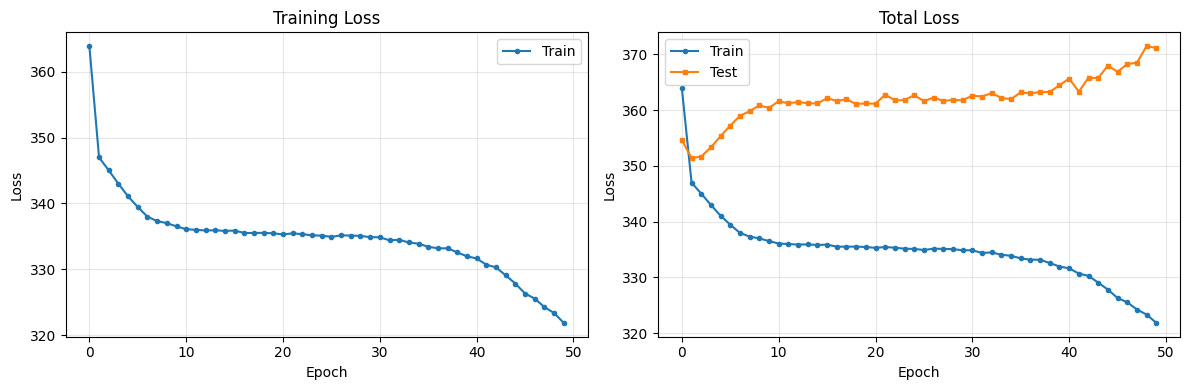

✓ Training history saved


In [5]:
# CELL 5: Plot Training History
Visualizer.plot_training_history(
    history,
    save_path=os.path.join(config.RESULTS_DIR, 'hard_training_history.png')
)
plt.show()

print("✓ Training history saved")


In [6]:
# Custom extraction for CVAE
def extract_cvae_latent(model, data_loader, device='cpu'):
    """Extract from Conditional VAE"""
    model.eval()
    latent_features = []
    genres_list = []
    ids_list = []
    
    with torch.no_grad():
        for batch in data_loader:
            if len(batch) == 3:
                features, genres, ids = batch
            else:
                features, ids = batch
                genres = torch.zeros(features.shape, dtype=torch.long)
            
            features = features.to(device)
            genres = genres.squeeze().to(device)
            
            _, _, _, z = model(features, genres)
            latent_features.append(z.cpu().numpy())
            genres_list.extend(genres.cpu().numpy())
            ids_list.extend(ids)
    
    return np.vstack(latent_features), np.array(genres_list), ids_list

all_loader = DataLoader(dataset, batch_size=config.BATCH_SIZE, shuffle=False)
latent_features, true_genres, ids = extract_cvae_latent(cvae, all_loader, device)

print(f"✓ Latent features: {latent_features.shape}")
print(f"✓ True genres shape: {true_genres.shape}")


✓ Latent features: (200, 40)
✓ True genres shape: (200,)


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    completeness_score
)

# K-Means clustering
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
predicted_labels = kmeans.fit_predict(latent_features)

# COMPUTE ALL METRICS
metrics_hard = {
    'Silhouette Score': silhouette_score(latent_features, predicted_labels),
    'Calinski-Harabasz': calinski_harabasz_score(latent_features, predicted_labels),
    'Davies-Bouldin': davies_bouldin_score(latent_features, predicted_labels),
    'Adjusted Rand Index (ARI)': adjusted_rand_score(true_genres, predicted_labels),
    'Normalized Mutual Info (NMI)': normalized_mutual_info_score(true_genres, predicted_labels),
    'Completeness Score': completeness_score(true_genres, predicted_labels),
}

print("\n" + "="*60)
print("HARD TASK - FULL METRICS")
print("="*60)
for metric_name, value in metrics_hard.items():
    print(f"{metric_name}: {value:.4f}")
print("="*60)

# Save
os.makedirs(os.path.join(config.RESULTS_DIR, 'metrics'), exist_ok=True)
metrics_df = pd.DataFrame([metrics_hard]).T
metrics_df.to_csv(
    os.path.join(config.RESULTS_DIR, 'metrics', 'hard_metrics.csv')
)



HARD TASK - FULL METRICS
Silhouette Score: 0.0438
Calinski-Harabasz: 8.5411
Davies-Bouldin: 2.7119
Adjusted Rand Index (ARI): 0.0122
Normalized Mutual Info (NMI): 0.1292
Completeness Score: 0.1353


Computing t-SNE (this may take a minute)...
✓ Saved: E:\vae-music-clustering\results\latent_visualization\hard_tsne.png


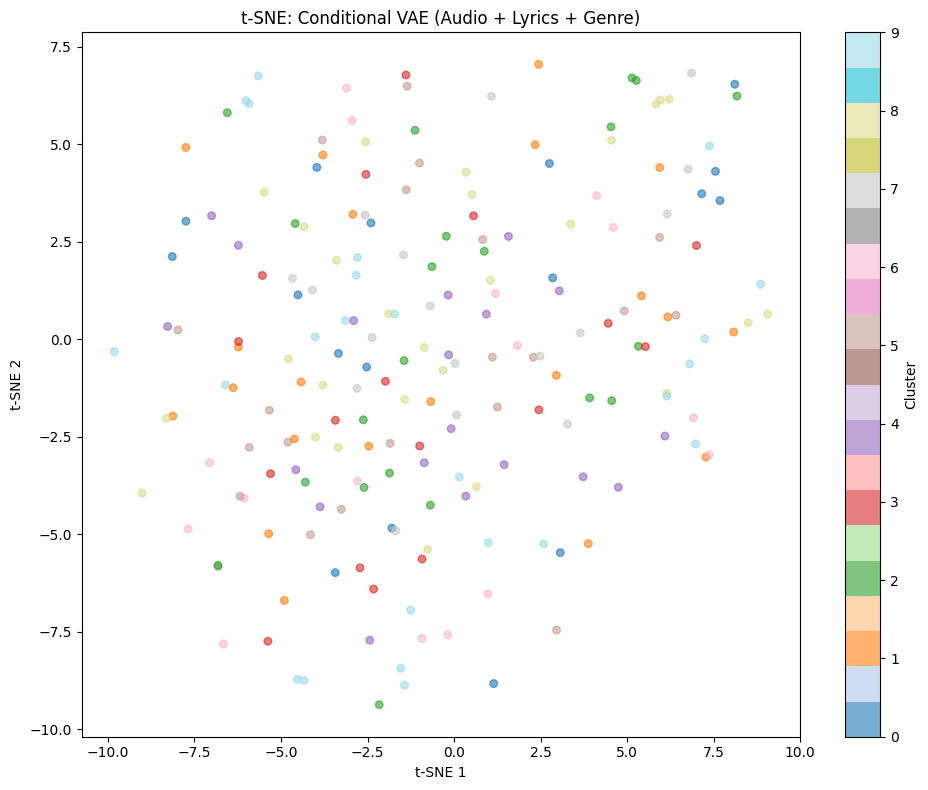

In [8]:
Visualizer.plot_tsne(
    latent_features,
    true_genres,  # Color by TRUE genres
    "t-SNE: Conditional VAE (Audio + Lyrics + Genre)",
    save_path=os.path.join(config.RESULTS_DIR, 'latent_visualization', 'hard_tsne.png')
)
plt.show()


In [9]:
print("\n" + "="*60)
print("GENRE-WISE ANALYSIS")
print("="*60)

for genre_id in range(n_genres):
    genre_name = dataset.idx_to_genre[genre_id]
    count = np.sum(true_genres == genre_id)
    print(f"  {genre_name}: {count} songs")

print("="*60)



GENRE-WISE ANALYSIS
  genre_0: 17 songs
  genre_1: 21 songs
  genre_2: 21 songs
  genre_3: 17 songs
  genre_4: 19 songs
  genre_5: 21 songs
  genre_6: 16 songs
  genre_7: 17 songs
  genre_8: 27 songs
  genre_9: 24 songs
